In [1]:
print("Notebook working!")

Notebook working!


In [7]:
import pandas as pd

df = pd.read_excel("../data/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [13]:
df.info()
df.isnull().sum()
df.shape
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [14]:
df[df['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [15]:
df = df.dropna(subset=['Description'])

In [16]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [17]:
df = df[df['Quantity'] > 0]

In [18]:
df = df[df['UnitPrice'] > 0]

In [19]:
df.info()
df.shape

<class 'pandas.DataFrame'>
Index: 530104 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    530104 non-null  object        
 1   StockCode    530104 non-null  object        
 2   Description  530104 non-null  object        
 3   Quantity     530104 non-null  int64         
 4   InvoiceDate  530104 non-null  datetime64[us]
 5   UnitPrice    530104 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      530104 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 36.4+ MB


(530104, 8)

In [20]:
df_uk = df[df['Country'] == 'United Kingdom']

In [21]:
basket = (df_uk
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum()
          .unstack()
          .fillna(0))

In [25]:
basket = (basket > 0).astype(int)
basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TOADSTOOL BEDSIDE LIGHT,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
from mlxtend.frequent_patterns import apriori, association_rules

In [27]:
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

c:\Users\ntj\Downloads\MSc DS\Course Codes\Data Mining\CW\Data_Mining_CW\.venv\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [32]:
frequent_itemsets.head()

,support,itemsets
0,0.020145,frozenset({3 HOOK PHOTO SHELF ANTIQUE WHITE})
1,0.024252,frozenset({3 STRIPEY MICE FELTCRAFT})
2,0.021810,frozenset({4 TRADITIONAL SPINNING TOPS})
3,0.047450,frozenset({6 RIBBONS RUSTIC CHARM})
4,0.020589,frozenset({60 CAKE CASES DOLLY GIRL DESIGN})


In [31]:
len(frequent_itemsets)

400

In [33]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)

In [34]:
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({PACK OF 72 RETROSPOT CAKE CASES}),frozenset({60 TEATIME FAIRY CAKE CASES}),0.062656,0.041789,0.022698,0.362267,8.668922,1.0,0.020080,1.502528,0.943779,0.277665,0.334455,0.452714
1,frozenset({60 TEATIME FAIRY CAKE CASES}),frozenset({PACK OF 72 RETROSPOT CAKE CASES}),0.041789,0.062656,0.022698,0.543161,8.668922,1.0,0.020080,2.051802,0.923226,0.277665,0.512624,0.452714
2,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED }),0.048615,0.051612,0.031245,0.642694,12.452370,1.0,0.028736,2.654274,0.966690,0.452936,0.623249,0.624035
3,frozenset({ALARM CLOCK BAKELIKE RED }),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.051612,0.048615,0.031245,0.605376,12.452370,1.0,0.028736,2.410866,0.969745,0.452936,0.585211,0.624035
4,frozenset({ALARM CLOCK BAKELIKE RED }),frozenset({ALARM CLOCK BAKELIKE PINK}),0.051612,0.036406,0.021810,0.422581,11.607440,1.0,0.019931,1.668794,0.963581,0.329422,0.400765,0.510833


In [37]:
len(rules)

184

In [38]:
rules_sorted = rules.sort_values(by='lift', ascending=False)

rules_sorted.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
161,frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),0.028248,0.026583,0.020423,0.722986,27.197263,1.0,0.019672,3.513966,0.991232,0.593548,0.715421,0.745627
162,frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),0.026583,0.028248,0.020423,0.768267,27.197263,1.0,0.019672,4.193416,0.989536,0.593548,0.761531,0.745627
168,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.038959,0.038848,0.027305,0.700855,18.041001,1.0,0.025791,3.212994,0.982862,0.540659,0.688764,0.701856
163,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.038848,0.038959,0.027305,0.702857,18.041001,1.0,0.025791,3.234273,0.982748,0.540659,0.690812,0.701856
165,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.030246,0.051723,0.027305,0.902752,17.453534,1.0,0.025740,9.751148,0.972107,0.499492,0.897448,0.715325
166,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.051723,0.030246,0.027305,0.527897,17.453534,1.0,0.025740,2.054116,0.994124,0.499492,0.513172,0.715325
164,"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.031966,0.053055,0.027305,0.854167,16.099612,1.0,0.025609,6.493336,0.968857,0.473077,0.845996,0.684406
167,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",0.053055,0.031966,0.027305,0.514644,16.099612,1.0,0.025609,1.994483,0.990434,0.473077,0.498617,0.684406
32,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.038959,0.051723,0.031966,0.820513,15.863541,1.0,0.029951,5.283257,0.974945,0.544423,0.810723,0.719269
31,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.051723,0.038959,0.031966,0.618026,15.863541,1.0,0.029951,2.515984,0.988068,0.544423,0.602541,0.719269


In [41]:
strong_rules = rules[
    (rules['confidence'] > 0.5) &
    (rules['lift'] > 5)
]

strong_rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,frozenset({60 TEATIME FAIRY CAKE CASES}),frozenset({PACK OF 72 RETROSPOT CAKE CASES}),0.041789,0.062656,0.022698,0.543161,8.668922,1.0,0.020080,2.051802,0.923226,0.277665,0.512624,0.452714
2,frozenset({ALARM CLOCK BAKELIKE GREEN}),frozenset({ALARM CLOCK BAKELIKE RED }),0.048615,0.051612,0.031245,0.642694,12.452370,1.0,0.028736,2.654274,0.966690,0.452936,0.623249,0.624035
3,frozenset({ALARM CLOCK BAKELIKE RED }),frozenset({ALARM CLOCK BAKELIKE GREEN}),0.051612,0.048615,0.031245,0.605376,12.452370,1.0,0.028736,2.410866,0.969745,0.452936,0.585211,0.624035
5,frozenset({ALARM CLOCK BAKELIKE PINK}),frozenset({ALARM CLOCK BAKELIKE RED }),0.036406,0.051612,0.021810,0.599085,11.607440,1.0,0.019931,2.365560,0.948375,0.329422,0.577267,0.510833
7,frozenset({CHARLOTTE BAG PINK POLKADOT}),frozenset({CHARLOTTE BAG SUKI DESIGN}),0.037349,0.044620,0.021311,0.570579,12.787652,1.0,0.019644,2.224813,0.957564,0.351327,0.550524,0.524096


In [42]:
len(strong_rules)

76

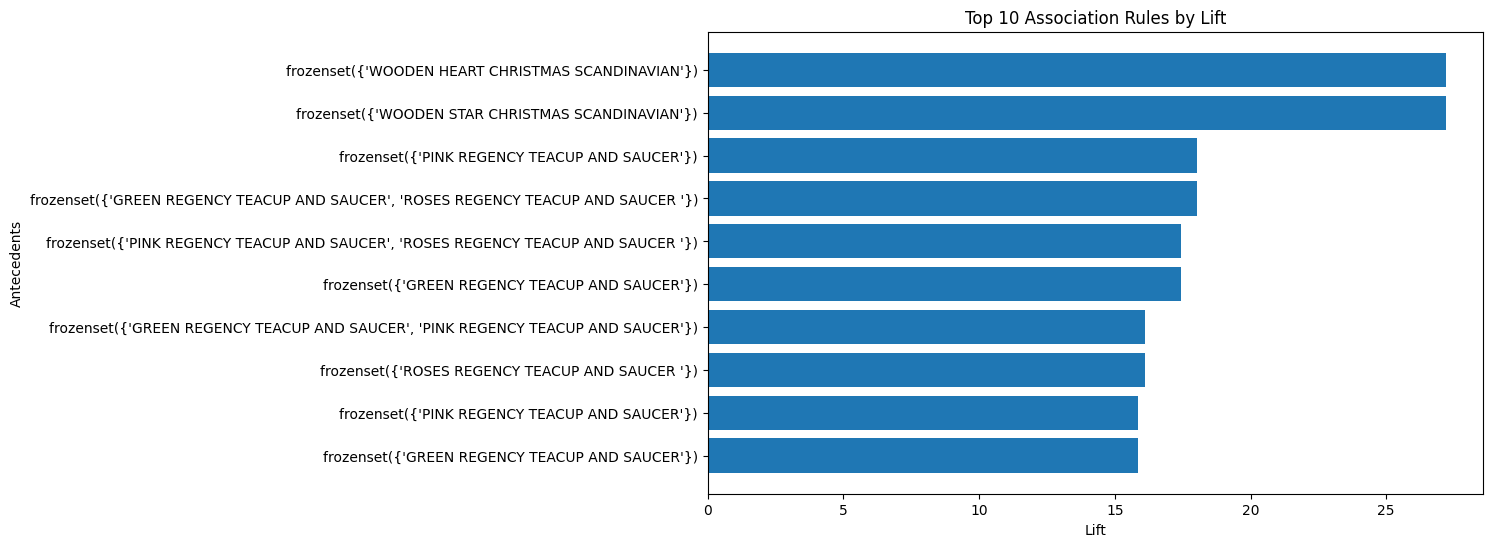

In [49]:
import matplotlib.pyplot as plt

top_rules = rules.sort_values(by='lift', ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    range(len(top_rules)),
    top_rules['lift']
)

plt.yticks(
    range(len(top_rules)),
    [str(x) for x in top_rules['antecedents']]
)

plt.xlabel("Lift")
plt.ylabel("Antecedents")
plt.title("Top 10 Association Rules by Lift")

plt.gca().invert_yaxis()

plt.savefig("../outputs/top_rules_lift.png", bbox_inches='tight')

plt.show()

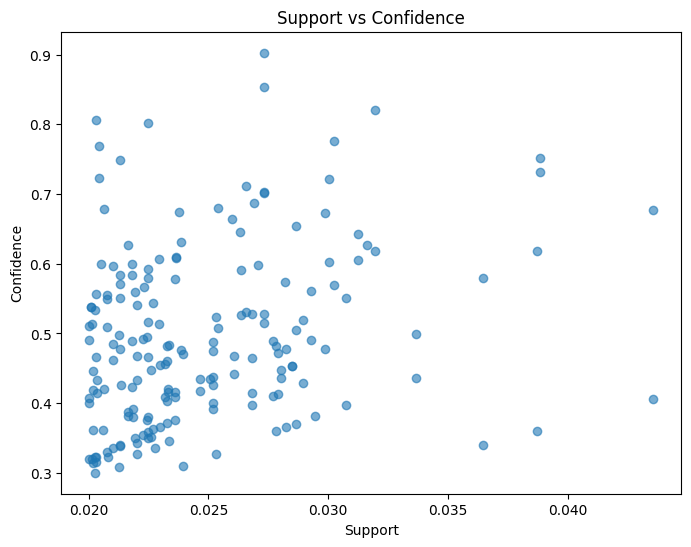

In [50]:
plt.figure(figsize=(8,6))

plt.scatter(
    rules['support'],
    rules['confidence'],
    alpha=0.6
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence")

plt.savefig("../outputs/support_confidence.png", bbox_inches='tight')
plt.show()

In [45]:
rules_sorted[['antecedents','consequents','support','confidence','lift']].head(10)

,antecedents,consequents,support,confidence,lift
161,frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),0.020423,0.722986,27.197263
162,frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),0.020423,0.768267,27.197263
168,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.027305,0.700855,18.041001
163,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.027305,0.702857,18.041001
165,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.027305,0.902752,17.453534
166,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.027305,0.527897,17.453534
164,"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.027305,0.854167,16.099612
167,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",0.027305,0.514644,16.099612
32,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.031966,0.820513,15.863541
31,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.031966,0.618026,15.863541


In [47]:
rules_sorted.to_csv("../outputs/association_rules.csv", index=False)
strong_rules.to_csv("../outputs/strong_rules.csv", index=False)

In [48]:
rules_sorted[['antecedents','consequents','support','confidence','lift']].head(10)

,antecedents,consequents,support,confidence,lift
161,frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),0.020423,0.722986,27.197263
162,frozenset({WOODEN STAR CHRISTMAS SCANDINAVIAN}),frozenset({WOODEN HEART CHRISTMAS SCANDINAVIAN}),0.020423,0.768267,27.197263
168,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.027305,0.700855,18.041001
163,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.027305,0.702857,18.041001
165,"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.027305,0.902752,17.453534
166,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({PINK REGENCY TEACUP AND SAUCER, ROS...",0.027305,0.527897,17.453534
164,"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.027305,0.854167,16.099612
167,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",0.027305,0.514644,16.099612
32,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.031966,0.820513,15.863541
31,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.031966,0.618026,15.863541
